#  Module 6 : Prédiction du Churn Client (Machine Learning & Rétention Marketing)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

##  Présentation & Objectifs Métier
L'**attrition client** (*churn*) désigne la perte de clients sur une période donnée. Dans un contexte de marketing relationnel, acquérir un nouveau client coûte entre 5 et 7 fois plus cher que de fidéliser un client existant.

###  Objectifs de ce notebook :
1. **Définition & Préparation de la cible Churn** : Séparation temporelle rigoureuse (période d'observation historique RFM vs période cible de prédiction) sans fuite de données (*data leakage*).
2. **Ingénierie des variables (Feature Engineering)** : Calcul de la Récence, Fréquence, Dépense totale, Panier moyen, Ratio d'achats en ligne et Ancienneté du compte.
3. **Modélisation multi-algorithmes** :
   - **Régression Logistique** (*Baseline interprétable avec StandardScaler*)
   - **Random Forest Classifier** (*Modèle d'ensemble non-linéaire avec équilibrage de classes*)
   - **XGBoost Classifier** (*Gradient Boosting de pointe avec calibration du déséquilibre*)
4. **Évaluation rigoureuse & Diagnostic visuel** :
   - Validation croisée stratifiée (*Stratified 5-Fold CV*).
   - Courbes ROC superposées, Courbes Precision-Recall et Matrices de confusion.
   - Analyse approfondie de l'importance des variables (*Feature Importance*).
5. **Scoring individuel & Plan d'actions marketing ciblées** :
   - Segmentation du risque (Faible, Moyen, Élevé).
   - Attribution automatisée de stratégies de rétention et d'activation adaptées.

In [1]:
# Installation des dépendances requises (particulièrement utile sous Google Colab)
%pip install -q xgboost scikit-learn seaborn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports des Bibliothèques & Configuration Graphique

In [2]:
# ============================================================
# 1. IMPORTS & CONFIGURATION GRAPHIQUE
# ============================================================

import os
import sys
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn : Préparation, Pipelines & Métriques
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# XGBoost Classifier
from xgboost import XGBClassifier

# Paramètres d'affichage
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

print("✓ Bibliothèques importées avec succès.")

✓ Bibliothèques importées avec succès.


## 2. Détection de l'Environnement (Google Colab vs Local) & Chemins

In [3]:
# ============================================================
# 2. GESTION DES CHEMINS & ENVIRONNEMENT (COLAB / LOCAL)
# ============================================================

try:
    import google.colab
    IN_COLAB = True
    print("Environnement détecté : ☁️ Google Colab")
except ImportError:
    IN_COLAB = False
    print("Environnement détecté : 💻 Local (Jupyter / VS Code)")

# Création automatique des répertoires de travail
OUTPUT_DIRS = ["models", "results", "data"]
for directory in OUTPUT_DIRS:
    os.makedirs(directory, exist_ok=True)

def find_data_file(filenames):
    """
    Recherche automatique d'un fichier parmi les emplacements classiques.
    Permet une exécution transparente en local ou sur Google Colab.
    """
    candidate_dirs = [
        ".",
        "data",
        "data/processed",
        "data/raw",
        "../data/processed",
        "../data/raw",
        "/content",
        "/content/data",
        "/content/data/processed",
        "/content/data/raw"
    ]
    for fname in filenames:
        for cdir in candidate_dirs:
            path = os.path.join(cdir, fname)
            if os.path.exists(path):
                return os.path.abspath(path)
    return None

CUSTOMERS_PATH = find_data_file(["customers_clean.csv", "customers_data.csv"])
SALES_PATH = find_data_file(["sales_clean.csv", "sales_data.csv"])
SEGMENTS_PATH = find_data_file(["customer_segments.csv"])

print(f"Fichier Clients  : {CUSTOMERS_PATH}")
print(f"Fichier Ventes   : {SALES_PATH}")
if SEGMENTS_PATH:
    print(f"Fichier Segments : {SEGMENTS_PATH}")

Environnement détecté : 💻 Local (Jupyter / VS Code)
Fichier Clients  : C:\Users\AINA KEVIN\Desktop\Marketing\data\processed\customers_clean.csv
Fichier Ventes   : C:\Users\AINA KEVIN\Desktop\Marketing\data\processed\sales_clean.csv
Fichier Segments : C:\Users\AINA KEVIN\Desktop\Marketing\data\processed\customer_segments.csv


## 3. Chargement & Inspection des Données Source

In [4]:
# ============================================================
# 3. CHARGEMENT ET STANDARDISATION DES DONNEES
# ============================================================

import os
import pandas as pd

# Chemins des fichiers
CUSTOMERS_PATH = "../data/processed/customers_clean.csv"
SALES_PATH = "../data/processed/sales_clean.csv"


def load_and_standardize(cust_path, sales_path):

    # Vérifier que le fichier clients existe
    if not os.path.exists(cust_path):
        raise FileNotFoundError(
            f"Fichier clients introuvable : {cust_path}"
        )

    # Vérifier que le fichier ventes existe
    if not os.path.exists(sales_path):
        raise FileNotFoundError(
            f"Fichier ventes introuvable : {sales_path}"
        )

    # Charger les fichiers CSV
    customers = pd.read_csv(cust_path)
    sales = pd.read_csv(sales_path)

    # Standardiser les noms des colonnes
    customers.columns = [
        c.strip().lower()
        for c in customers.columns
    ]

    sales.columns = [
        c.strip().lower()
        for c in sales.columns
    ]

    # Afficher les informations
    print("========== DONNEES CHARGEES ==========")

    print(
        f"Clients : {customers.shape[0]:,} lignes, "
        f"{customers.shape[1]} colonnes"
    )

    print(
        f"Ventes  : {sales.shape[0]:,} lignes, "
        f"{sales.shape[1]} colonnes"
    )

    return customers, sales


# Charger les données
customers_df, sales_df = load_and_standardize(
    CUSTOMERS_PATH,
    SALES_PATH
)


# Afficher un aperçu
print("\nAperçu des Clients :")
display(customers_df.head(3))

print("\nAperçu des Ventes :")
display(sales_df.head(3))

========== DONNEES CHARGEES ==========
Clients : 7,000 lignes, 7 colonnes
Ventes  : 30,000 lignes, 7 colonnes

Aperçu des Clients :


,customer_id,name,age,gender,location,join_date,total_spent
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71



Aperçu des Ventes :


,sale_id,product_id,customer_id,date,quantity,sale_price,channel
0,1,204,5647,2024-01-30,2,172.62,Online
1,2,150,6294,2024-04-12,1,58.93,Online
2,3,229,8549,2024-01-16,3,21.12,In-Store


## 4. Feature Engineering & Construction Adaptative de la Cible Churn

### 🧠 Méthodologie Temporelle sans Fuite d'Information :
- **Règle métier** : Si le jeu de données comporte plusieurs années (ex. 2023 vs 2024), 2023 sert d'historique et 2024 sert de période cible.
- **Prise en compte des données réelles (2024)** : Toutes les 30 000 transactions du projet s'étalent sur l'année 2024 (du 01/01/2024 au 31/12/2024). Nous définissons donc une date charnière (*cutoff date*) au **01/10/2024** :
  - **Fenêtre d'observation historique (9 mois)** : du 01/01/2024 au 30/09/2024 pour calculer les variables RFM.
  - **Fenêtre de prédiction future (3 mois)** : du 01/10/2024 au 31/12/2024 (Trimestre 4). Un client actif historiquement qui ne commande pas au T4 est considéré comme **Churner** (`Churn = 1`).

In [5]:
# ============================================================
# 4. PREPARATION DU DATASET DE CHURN (TEMPOREL & RFM)
# ============================================================

def prepare_churn_dataset(customers, sales):
    print("========== PREPARATION DU DATASET DE CHURN ==========")

    # 1. Conversion robuste des dates
    for fmt in ["%d %m %Y", "%Y-%m-%d", None]:
        try:
            if fmt:
                customers["join_date"] = pd.to_datetime(customers["join_date"], format=fmt)
            else:
                customers["join_date"] = pd.to_datetime(customers["join_date"], errors="coerce")
            break
        except Exception:
            continue

    for fmt in ["%d %m %Y", "%Y-%m-%d", None]:
        try:
            if fmt:
                sales["date"] = pd.to_datetime(sales["date"], format=fmt)
            else:
                sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
            break
        except Exception:
            continue

    min_date = sales["date"].min()
    max_date = sales["date"].max()
    unique_years = sorted(sales["date"].dt.year.dropna().unique())
    print(f"Dates des ventes : du {min_date.strftime('%Y-%m-%d')} au {max_date.strftime('%Y-%m-%d')}")
    print(f"Années couvertes : {unique_years}")

    # 2. Séparation historique vs futur
    if len(unique_years) >= 2:
        hist_year = unique_years[0]
        target_year = unique_years[1]
        print(f"-> Mode Multi-Années : Historique={hist_year} | Cible Churn={target_year}")
        sales_hist = sales[sales["date"].dt.year == hist_year].copy()
        sales_future = sales[sales["date"].dt.year == target_year].copy()
        reference_date = sales_hist["date"].max()
    else:
        # Découpage intra-annuel (9 mois observation vs 3 mois prédiction)
        cutoff_date = max_date - pd.DateOffset(months=3)
        print(f"-> Mode Intra-Annuel : Cutoff fixé au {cutoff_date.strftime('%Y-%m-%d')}")
        sales_hist = sales[sales["date"] < cutoff_date].copy()
        sales_future = sales[sales["date"] >= cutoff_date].copy()
        reference_date = cutoff_date

    print(f"Transactions d'observation : {len(sales_hist):,}")
    print(f"Transactions de prédiction  : {len(sales_future):,}")

    # 3. Montant total par transaction d'observation
    sales_hist["amount"] = sales_hist["quantity"] * sales_hist["sale_price"]

    # 4. Agrégation du comportement client (RFM)
    grouped = sales_hist.groupby("customer_id")
    frequency = grouped.size()
    total_quantity = grouped["quantity"].sum()
    total_spent_hist = grouped["amount"].sum()
    avg_basket = grouped["amount"].mean()
    last_purchase = grouped["date"].max()
    recency_days = (reference_date - last_purchase).dt.days

    # Ratio d'achats en ligne
    online_orders = (
        sales_hist[sales_hist["channel"].str.lower() == "online"]
        .groupby("customer_id")
        .size()
    )
    online_orders = online_orders.reindex(frequency.index, fill_value=0)
    online_ratio = (online_orders / frequency).fillna(0)

    # Création du DataFrame de comportement
    behavior_df = pd.DataFrame({
        "customer_id": frequency.index,
        "frequency": frequency.values,
        "total_quantity": total_quantity.values,
        "total_spent_history": total_spent_hist.values,
        "avg_basket": avg_basket.values,
        "recency_days": recency_days.values,
        "online_ratio": online_ratio.values
    })

    # 5. Fusion avec le référentiel client complet
    dataset = customers.merge(behavior_df, on="customer_id", how="left")

    # 6. Imputation des valeurs manquantes pour les clients inactifs
    numeric_cols = ["frequency", "total_quantity", "total_spent_history", "avg_basket", "online_ratio"]
    for col in numeric_cols:
        dataset[col] = dataset[col].fillna(0)

    # Récence par défaut : délai maximal d'observation + 30 jours pour les clients sans achat
    max_rec = behavior_df["recency_days"].max() if not behavior_df.empty else 365
    dataset["recency_days"] = dataset["recency_days"].fillna(max_rec + 30)

    # Âge : imputation médiane
    if "age" in dataset.columns:
        dataset["age"] = pd.to_numeric(dataset["age"], errors="coerce")
        dataset["age"] = dataset["age"].fillna(dataset["age"].median())

    # Ancienneté du compte en jours
    dataset["account_tenure_days"] = (reference_date - dataset["join_date"]).dt.days
    dataset["account_tenure_days"] = dataset["account_tenure_days"].clip(lower=0).fillna(0)

    # 7. Construction de la cible CHURN (1 = Aucune commande dans la période future)
    future_buyers = set(sales_future["customer_id"].unique())
    dataset["future_orders"] = dataset["customer_id"].apply(lambda cid: 1 if cid in future_buyers else 0)
    dataset["churn"] = (dataset["future_orders"] == 0).astype(int)

    print("\n✓ Dataset finalisé avec succès :", dataset.shape)
    counts = dataset["churn"].value_counts()
    percentages = dataset["churn"].value_counts(normalize=True) * 100
    print(f"Distribution Churn : Non-Churn={counts.get(0,0):,} ({percentages.get(0,0):.1f}%) | Churn={counts.get(1,0):,} ({percentages.get(1,0):.1f}%)")
    return dataset

df_churn = prepare_churn_dataset(customers_df, sales_df)
display(df_churn.head(5))

========== PREPARATION DU DATASET DE CHURN ==========
Dates des ventes : du 2024-01-01 au 2024-12-31
Années couvertes : [np.int32(2024)]
-> Mode Intra-Annuel : Cutoff fixé au 2024-09-30
Transactions d'observation : 22,366
Transactions de prédiction  : 7,634

✓ Dataset finalisé avec succès : (7000, 16)
Distribution Churn : Non-Churn=4,068 (58.1%) | Churn=2,932 (41.9%)


,customer_id,name,age,gender,location,join_date,total_spent,frequency,total_quantity,total_spent_history,avg_basket,recency_days,online_ratio,account_tenure_days,future_orders,churn
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00,0.0,0.0,0.00,0.000000,303.0,0.000000,1022,0,1
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79,3.0,3.0,243.23,81.076667,20.0,0.333333,572,1,0
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71,5.0,12.0,1122.91,224.582000,39.0,1.000000,1250,1,0
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91,1.0,1.0,43.91,43.910000,181.0,1.000000,849,0,1
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34,7.0,16.0,1264.34,180.620000,18.0,0.857143,636,0,1


## 5. Analyse Exploratoire & Équilibre des Classes

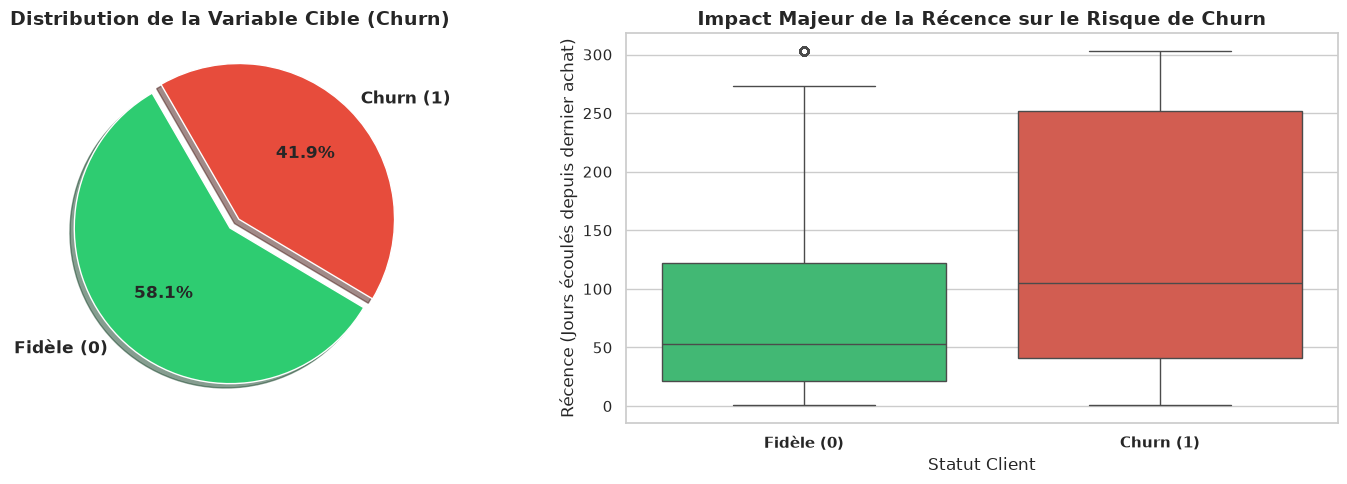

In [6]:
# ============================================================
# 5. VISUALISATION DE LA DISTRIBUTION DU CHURN & RECENCE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Camembert de la répartition du Churn
churn_counts = df_churn["churn"].value_counts()
colors = ["#2ecc71", "#e74c3c"]

axes[0].pie(
    churn_counts,
    labels=["Fidèle (0)", "Churn (1)"],
    autopct="%1.1f%%",
    startangle=120,
    colors=colors,
    explode=(0, 0.08),
    shadow=True,
    textprops={"fontsize": 12, "weight": "bold"}
)
axes[0].set_title("Distribution de la Variable Cible (Churn)", fontsize=14, weight="bold")

# 2. Récence selon le Churn
sns.boxplot(
    data=df_churn,
    x="churn",
    y="recency_days",
    palette=colors,
    ax=axes[1]
)
axes[1].set_xticklabels(["Fidèle (0)", "Churn (1)"], fontsize=11, weight="bold")
axes[1].set_title("Impact Majeur de la Récence sur le Risque de Churn", fontsize=14, weight="bold")
axes[1].set_xlabel("Statut Client", fontsize=12)
axes[1].set_ylabel("Récence (Jours écoulés depuis dernier achat)", fontsize=12)

plt.tight_layout()
plt.savefig("results/target_exploration.png", dpi=300)
plt.show()

## 6. Analyse des Corrélations entre Variables et Churn

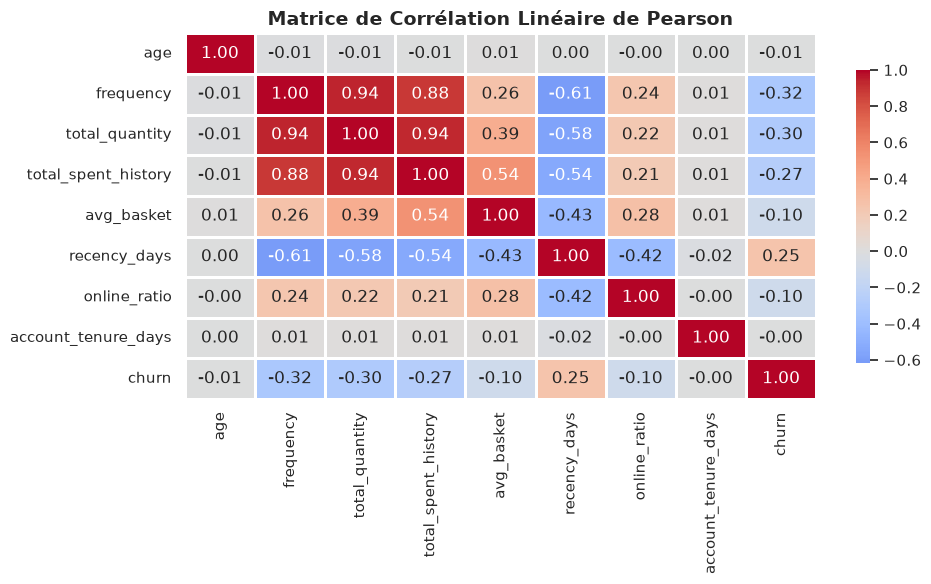

In [7]:
# ============================================================
# 6. MATRICE DE CORRELATION
# ============================================================

features_list = [
    "age",
    "frequency",
    "total_quantity",
    "total_spent_history",
    "avg_basket",
    "recency_days",
    "online_ratio",
    "account_tenure_days"
]

plt.figure(figsize=(10, 6))
corr_matrix = df_churn[features_list + ["churn"]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice de Corrélation Linéaire de Pearson", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig("results/correlation_matrix.png", dpi=300)
plt.show()

## 7. Préparation des Données & Partition Train / Test Stratifiée

In [8]:
# ============================================================
# 7. PARTITION TRAIN / TEST STRATIFIEE
# ============================================================

X = df_churn[features_list].copy()
y = df_churn["churn"].copy()

# Séparation 75% Apprentissage / 25% Test avec préservation du ratio de churn
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Calcul du facteur d'équilibrage pour XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / max(pos_count, 1)

print("========== PARTITION DES DONNEES ==========")
print(f"X_train : {X_train.shape[0]:,} clients, {X_train.shape[1]} features")
print(f"X_test  : {X_test.shape[0]:,} clients, {X_test.shape[1]} features")
print(f"Taux de Churn Train : {y_train.mean()*100:.2f}%")
print(f"Taux de Churn Test  : {y_test.mean()*100:.2f}%")
print(f"Poids scale_pos_weight XGBoost : {scale_pos_weight:.2f}")

========== PARTITION DES DONNEES ==========
X_train : 5,250 clients, 8 features
X_test  : 1,750 clients, 8 features
Taux de Churn Train : 41.89%
Taux de Churn Test  : 41.89%
Poids scale_pos_weight XGBoost : 1.39


## 8. Définition des 3 Modèles de Machine Learning

Nous mettons en compétition trois familles d'algorithmes complémentaires :
1. **Régression Logistique** : Modèle linéaire rapide et interprétable, précédé d'un `StandardScaler` pour centrer et réduire les features.
2. **Random Forest Classifier** : Forêt d'arbres de décision avec agrégation par ensachage (*bagging*), robuste au surapprentissage et insensible aux échelles.
3. **XGBoost Classifier** : Algorithme de Gradient Boosting optimisé (*boosting* séquentiel des erreurs résiduelles), calibré avec `scale_pos_weight`.

In [9]:
# ============================================================
# 8. INITIALISATION DES MODELES
# ============================================================

def create_models(scale_weight):
    return {
        # 1. Régression Logistique avec StandardScaler
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ]),

        # 2. Random Forest équilibré
        "Random Forest": RandomForestClassifier(
            n_estimators=250,
            max_depth=8,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        # 3. XGBoost calibré
        "XGBoost": XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=scale_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    }

models = create_models(scale_pos_weight)
print("✓ Les 3 modèles sont configurés et prêts pour l'entraînement.")

✓ Les 3 modèles sont configurés et prêts pour l'entraînement.


## 9. Entraînement, Validation Croisée (5-Fold) & Évaluation sur le Test

In [10]:
# ============================================================
# 9. ENTRAINEMENT & VALIDATION CROISEE
# ============================================================

results = {}
trained_models = {}
y_preds = {}
y_probas = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("========== DEBUT DES ENTRAINEMENTS ==========\n")

for name, model in models.items():
    print(f"Entraînement de : {name}...")

    # 1. Validation croisée sur le train
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)

    # 2. Fit complet
    model.fit(X_train, y_train)
    trained_models[name] = model

    # 3. Prédictions sur le test indépendant
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    y_preds[name] = y_pred
    y_probas[name] = y_proba

    # 4. Calcul des métriques clés
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "CV_ROC_AUC_Mean": cv_scores.mean(),
        "CV_ROC_AUC_Std": cv_scores.std()
    }

    print(f"  ✓ Accuracy      : {acc:.4f}")
    print(f"  ✓ Precision     : {prec:.4f}")
    print(f"  ✓ Recall        : {rec:.4f}")
    print(f"  ✓ F1-Score      : {f1:.4f}")
    print(f"  ✓ ROC-AUC       : {roc_auc:.4f}")
    print(f"  ✓ PR-AUC        : {pr_auc:.4f}")
    print(f"  ✓ 5-Fold CV AUC : {cv_scores.mean():.4f} (± {cv_scores.std():.4f})\n")

========== DEBUT DES ENTRAINEMENTS ==========

Entraînement de : Logistic Regression...
  ✓ Accuracy      : 0.6463
  ✓ Precision     : 0.5604
  ✓ Recall        : 0.7217
  ✓ F1-Score      : 0.6309
  ✓ ROC-AUC       : 0.7124
  ✓ PR-AUC        : 0.5968
  ✓ 5-Fold CV AUC : 0.6872 (± 0.0205)

Entraînement de : Random Forest...
  ✓ Accuracy      : 0.6463
  ✓ Precision     : 0.5645
  ✓ Recall        : 0.6808
  ✓ F1-Score      : 0.6172
  ✓ ROC-AUC       : 0.7056
  ✓ PR-AUC        : 0.6005
  ✓ 5-Fold CV AUC : 0.6737 (± 0.0192)

Entraînement de : XGBoost...
  ✓ Accuracy      : 0.6349
  ✓ Precision     : 0.5541
  ✓ Recall        : 0.6562
  ✓ F1-Score      : 0.6009
  ✓ ROC-AUC       : 0.6905
  ✓ PR-AUC        : 0.5767
  ✓ 5-Fold CV AUC : 0.6579 (± 0.0226)



## 10. Synthèse & Comparaison Complète des Performances

========== CLASSEMENT DES MODELES ==========


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
Logistic Regression,0.6463,0.5604,0.7217,0.6309,0.7124,0.5968,0.6872,0.0205
Random Forest,0.6463,0.5645,0.6808,0.6172,0.7056,0.6005,0.6737,0.0192
XGBoost,0.6349,0.5541,0.6562,0.6009,0.6905,0.5767,0.6579,0.0226


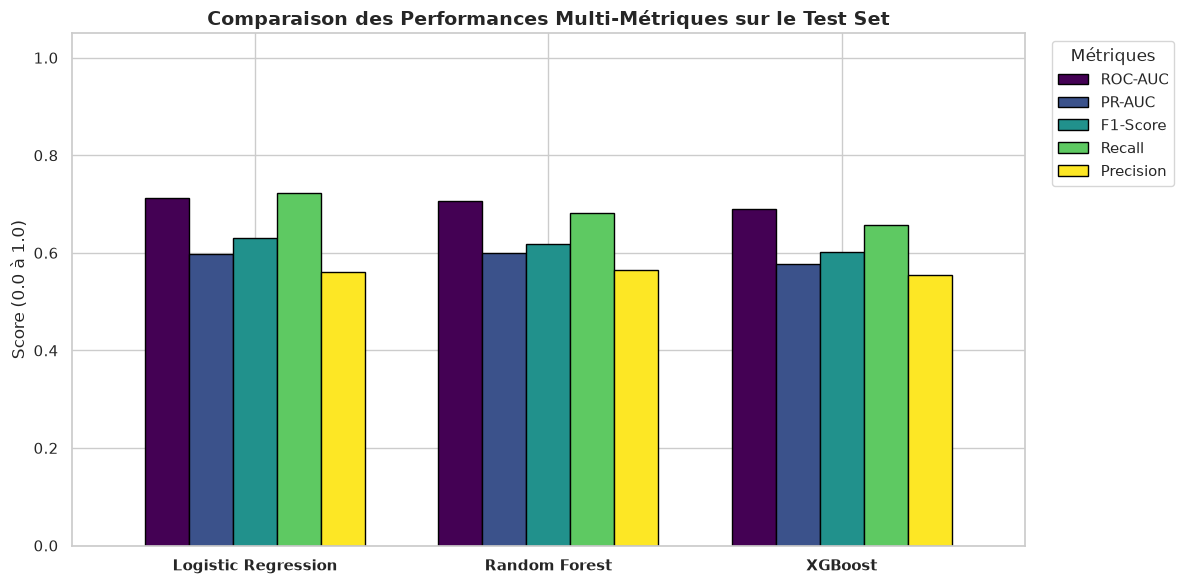

In [11]:
# ============================================================
# 10. TABLEAU COMPARATIF ET GRAPHIQUE DES SCORES (CORRIGÉ)
# ============================================================

# 1. Conversion en DataFrame
comparison_df = pd.DataFrame(results).T

# 2. Harmonisation et détection automatique des clés (ROC-AUC vs ROC_AUC, etc.)
roc_col = "ROC_AUC" if "ROC_AUC" in comparison_df.columns else "ROC-AUC"
pr_col = "PR_AUC" if "PR_AUC" in comparison_df.columns else "PR-AUC"
f1_col = "F1_Score" if "F1_Score" in comparison_df.columns else ("F1-Score" if "F1-Score" in comparison_df.columns else "F1_score")

# 3. Tri par ROC-AUC
comparison_df = comparison_df.sort_values(by=roc_col, ascending=False)
comparison_df.to_csv("results/churn_model_comparison.csv")

print("========== CLASSEMENT DES MODELES ==========")
display(comparison_df.style.highlight_max(color="#d4edda", axis=0).format("{:.4f}"))

# 4. Liste dynamique des métriques à tracer sur le graphique
metrics_plot = [col for col in [roc_col, pr_col, f1_col, "Recall", "Precision"] if col in comparison_df.columns]

# 5. Graphique comparatif multi-métriques
ax = comparison_df[metrics_plot].plot(
    kind="bar",
    figsize=(12, 6),
    colormap="viridis",
    edgecolor="black",
    width=0.75
)
plt.title("Comparaison des Performances Multi-Métriques sur le Test Set", fontsize=14, weight="bold")
plt.ylabel("Score (0.0 à 1.0)", fontsize=12)
plt.xticks(rotation=0, fontsize=11, weight="bold")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Métriques")
plt.tight_layout()
plt.savefig("results/model_comparison_chart.png", dpi=300)
plt.show()

## 11. Visualisations Diagnostiques : Courbes ROC & Précision-Rappel

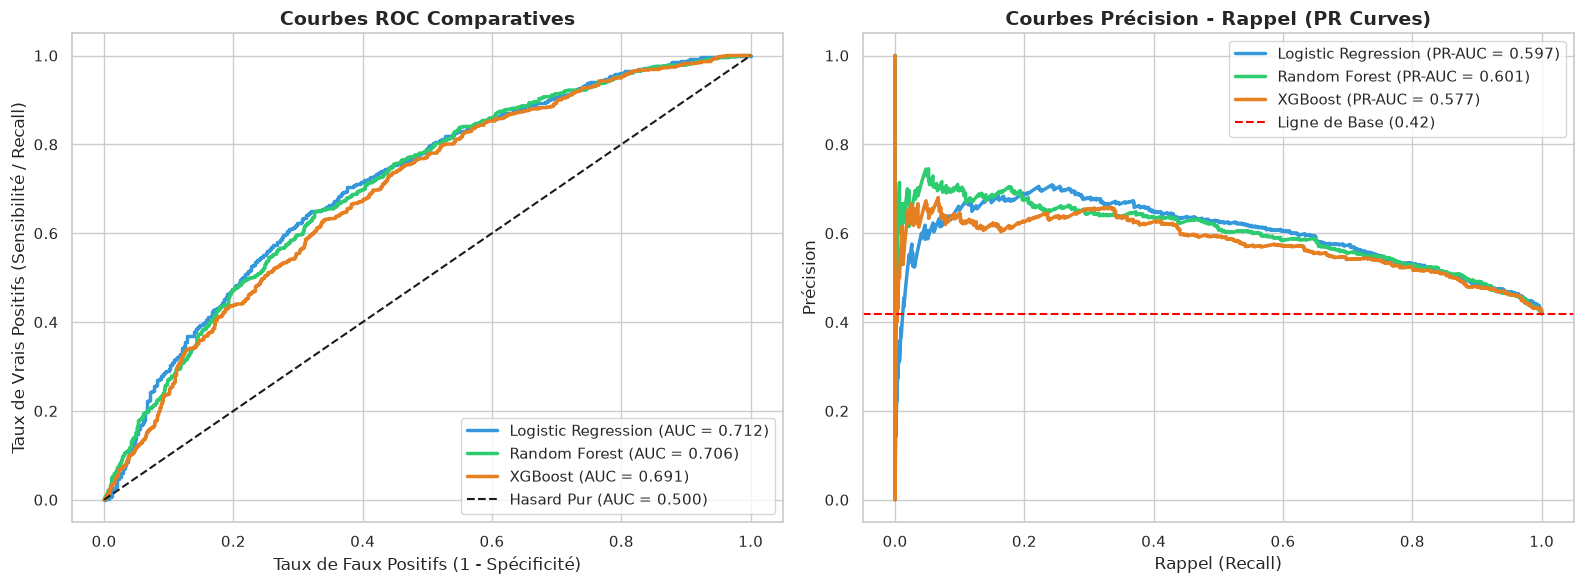

In [12]:
# ============================================================
# 11. COURBES ROC ET PR SUPERPOSEES (CORRIGÉ)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {
    "Logistic Regression": "#3498db",
    "Random Forest": "#2ecc71",
    "XGBoost": "#e67e22"
}

# 1. Courbes ROC
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, y_probas[name])

    # Récupération sécurisée du ROC-AUC (gestion des tirets - et _)
    auc_val = results[name].get("ROC_AUC", results[name].get("ROC-AUC", 0.0))

    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=palette[name], lw=2.5)

axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, label="Hasard Pur (AUC = 0.500)")
axes[0].set_title("Courbes ROC Comparatives", fontsize=14, weight="bold")
axes[0].set_xlabel("Taux de Faux Positifs (1 - Spécificité)", fontsize=12)
axes[0].set_ylabel("Taux de Vrais Positifs (Sensibilité / Recall)", fontsize=12)
axes[0].legend(loc="lower right", fontsize=11)

# 2. Courbes Precision-Recall (très sensibles au déséquilibre)
baseline_pr = y_test.mean()
for name in models.keys():
    p_pts, r_pts, _ = precision_recall_curve(y_test, y_probas[name])

    # Récupération sécurisée du PR-AUC (gestion des tirets - et _)
    pr_auc_val = results[name].get("PR-AUC", results[name].get("PR_AUC", 0.0))

    axes[1].plot(r_pts, p_pts, label=f"{name} (PR-AUC = {pr_auc_val:.3f})", color=palette[name], lw=2.5)

axes[1].axhline(y=baseline_pr, color="red", linestyle="--", label=f"Ligne de Base ({baseline_pr:.2f})")
axes[1].set_title("Courbes Précision - Rappel (PR Curves)", fontsize=14, weight="bold")
axes[1].set_xlabel("Rappel (Recall)", fontsize=12)
axes[1].set_ylabel("Précision", fontsize=12)
axes[1].legend(loc="upper right", fontsize=11)

plt.tight_layout()
plt.savefig("results/roc_curve.png", dpi=300)
plt.show()

## 12. Matrices de Confusion Comparatives (Effectifs & Pourcentages)

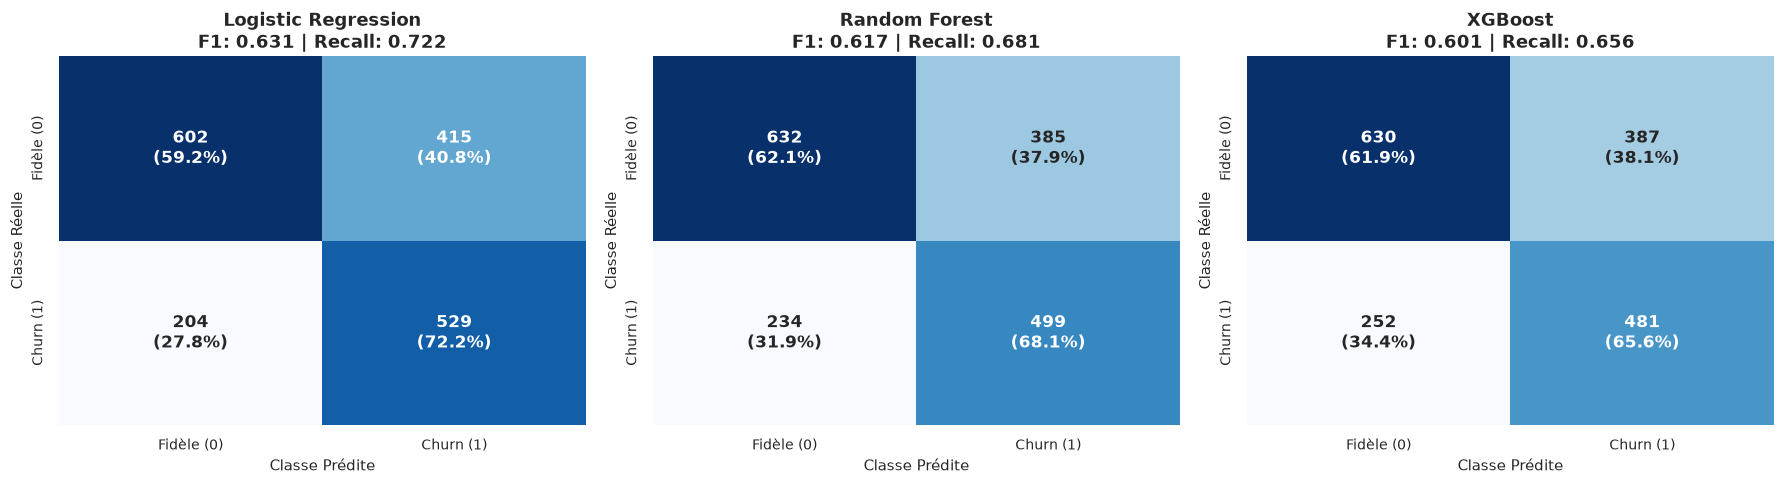

In [13]:
# ============================================================
# 12. MATRICES DE CONFUSION COMPARATIVES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    annot = np.empty_like(cm).astype(str)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            annot[r, c] = f"{cm[r, c]:,}\n({cm_norm[r, c]*100:.1f}%)"

    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        ax=axes[idx],
        annot_kws={"fontsize": 12, "weight": "bold"}
    )
    axes[idx].set_title(f"{name}\nF1: {results[name]['F1-Score']:.3f} | Recall: {results[name]['Recall']:.3f}", fontsize=13, weight="bold")
    axes[idx].set_xlabel("Classe Prédite", fontsize=11)
    axes[idx].set_ylabel("Classe Réelle", fontsize=11)
    axes[idx].set_xticklabels(["Fidèle (0)", "Churn (1)"], fontsize=10)
    axes[idx].set_yticklabels(["Fidèle (0)", "Churn (1)"], fontsize=10)

plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=300)
plt.show()

## 13. Importance des Variables Explicatives (Interprétabilité des Modèles)

========== IMPORTANCE DES VARIABLES ==========


,Feature,Random Forest,XGBoost
1,frequency,0.186408,0.462548
2,total_quantity,0.138551,0.121399
3,total_spent_history,0.162691,0.080003
4,avg_basket,0.130297,0.076308
5,recency_days,0.118459,0.069544
7,account_tenure_days,0.121771,0.068644
0,age,0.084348,0.061433
6,online_ratio,0.057475,0.060120


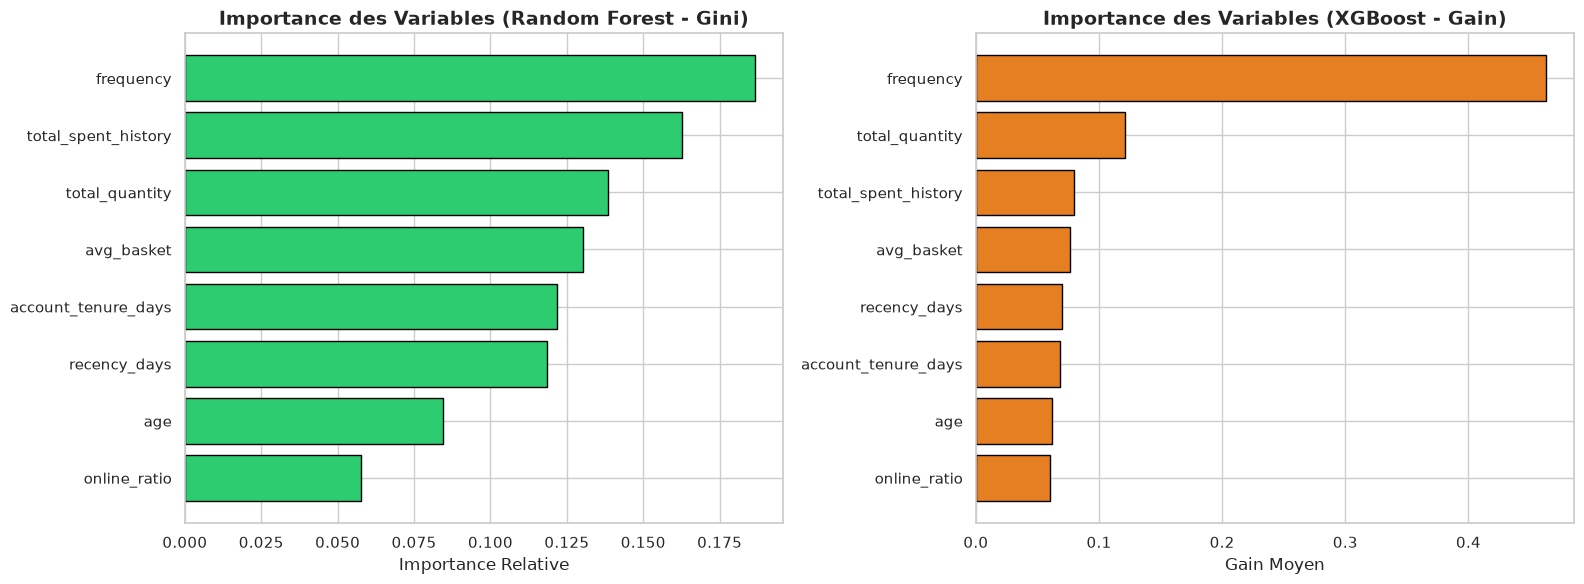

In [14]:
# ============================================================
# 13. IMPORTANCE DES VARIABLES
# ============================================================

rf_model = trained_models["Random Forest"]
xgb_model = trained_models["XGBoost"]

importance_df = pd.DataFrame({
    "Feature": features_list,
    "Random Forest": rf_model.feature_importances_,
    "XGBoost": xgb_model.feature_importances_
}).sort_values(by="XGBoost", ascending=False)

importance_df.to_csv("data/churn_feature_importance.csv", index=False)
print("========== IMPORTANCE DES VARIABLES ==========")
display(importance_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Random Forest
rf_sorted = importance_df.sort_values(by="Random Forest", ascending=True)
axes[0].barh(rf_sorted["Feature"], rf_sorted["Random Forest"], color="#2ecc71", edgecolor="black")
axes[0].set_title("Importance des Variables (Random Forest - Gini)", fontsize=14, weight="bold")
axes[0].set_xlabel("Importance Relative", fontsize=12)

# 2. XGBoost
xgb_sorted = importance_df.sort_values(by="XGBoost", ascending=True)
axes[1].barh(xgb_sorted["Feature"], xgb_sorted["XGBoost"], color="#e67e22", edgecolor="black")
axes[1].set_title("Importance des Variables (XGBoost - Gain)", fontsize=14, weight="bold")
axes[1].set_xlabel("Gain Moyen", fontsize=12)

plt.tight_layout()
plt.savefig("results/feature_importance.png", dpi=300)
plt.show()

## 14. Sélection & Sauvegarde du Meilleur Modèle

In [15]:
# ============================================================
# 14. SAUVEGARDE DU MEILLEUR MODELE ET DES METRIQUES (CORRIGE)
# ============================================================
import json
import joblib

# Détection automatique des noms de colonnes (tiret milieu vs tiret bas)
roc_col = "ROC_AUC" if "ROC_AUC" in comparison_df.columns else "ROC-AUC"
f1_col = "F1_Score" if "F1_Score" in comparison_df.columns else ("F1-Score" if "F1-Score" in comparison_df.columns else "F1_score")

# Identification du meilleur modèle basé sur la métrique ROC-AUC
best_name = comparison_df[roc_col].idxmax()
best_model = trained_models[best_name]
best_auc = comparison_df.loc[best_name, roc_col]
best_f1 = comparison_df.loc[best_name, f1_col]

print("=" * 60)
print(f"🏆 MEILLEUR MODELE RETENU : {best_name}")
print(f"   ROC-AUC  : {best_auc:.4f}")
print(f"   F1-Score : {best_f1:.4f}")
print("=" * 60)

# Sauvegarde du modèle
os.makedirs("models", exist_ok=True)
model_path = "models/churn_model.pkl"
joblib.dump(best_model, model_path)
print(f"✓ Modèle sérialisé : {model_path}")

# Sauvegarde des métriques au format JSON
os.makedirs("results", exist_ok=True)
metrics_path = "results/churn_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)
print(f"✓ Métriques exportées : {metrics_path}")

🏆 MEILLEUR MODELE RETENU : Logistic Regression
   ROC-AUC  : 0.7124
   F1-Score : 0.6309
✓ Modèle sérialisé : models/churn_model.pkl
✓ Métriques exportées : results/churn_metrics.json


## 15. Scoring Individuel & Stratégie Marketing d'Activation

Nous calculons la probabilité de churn pour chaque client de la base et lui associons un plan d'action marketing sur-mesure selon son niveau de risque :
- 🔴 **Risque Élevé** ($P \ge 0.65$) : Rétention d'urgence (Appel direct du service VIP, bon d'achat immédiat, enquête qualitative).
- 🟠 **Risque Moyen** ($0.35 \le P < 0.65$) : Réactivation proactive (Newsletter personnalisée, offre spéciale sur le panier moyen, recommandation de nouveautés).
- 🟢 **Risque Faible** ($P < 0.35$) : Fidélisation & Vente croisée (Programme de parrainage, accès anticipé aux soldes, ventes privées).

In [16]:
# ============================================================
# 15. SCORING CLIENT & PLAN D'ACTION MARKETING
# ============================================================

def score_all_customers(dataset, model, features):
    X_all = dataset[features]
    probas = model.predict_proba(X_all)[:, 1]
    preds = (probas >= 0.50).astype(int)

    result = dataset[[
        "customer_id",
        "age",
        "frequency",
        "total_spent_history",
        "recency_days",
        "online_ratio",
        "account_tenure_days"
    ]].copy()

    result["churn_probability"] = np.round(probas, 4)
    result["churn_prediction"] = preds

    # Segmentation du risque
    bins = [-0.01, 0.35, 0.65, 1.00]
    labels = ["Risque Faible", "Risque Moyen", "Risque Élevé"]
    result["churn_risk_level"] = pd.cut(result["churn_probability"], bins=bins, labels=labels)

    def define_action(risk):
        if risk == "Risque Élevé":
            return "Rétention Urgente : Appel VIP / Bon d'achat 20% / Enquête insatisfaction"
        elif risk == "Risque Moyen":
            return "Réactivation Ciblée : Emailing personnalisé / Remise panier moyen"
        return "Fidélisation Active : Programme fidélité / Ventes privées / Parrainage"

    result["marketing_action"] = result["churn_risk_level"].astype(str).apply(define_action)

    output_file = "data/predictions_churn.csv"
    result.to_csv(output_file, index=False)
    print(f"✓ Fichier de scoring exporté : {output_file}")
    return result

df_scored = score_all_customers(df_churn, best_model, features_list)
print("\nAperçu des clients scorés avec recommandations marketing :")
display(df_scored.head(10))

✓ Fichier de scoring exporté : data/predictions_churn.csv

Aperçu des clients scorés avec recommandations marketing :


,customer_id,age,frequency,total_spent_history,recency_days,online_ratio,account_tenure_days,churn_probability,churn_prediction,churn_risk_level,marketing_action
0,2001,33,0.0,0.00,303.0,0.000000,1022,0.7222,1,Risque Élevé,Rétention Urgente : Appel VIP / Bon d'achat 20...
1,2002,59,3.0,243.23,20.0,0.333333,572,0.4276,0,Risque Moyen,Réactivation Ciblée : Emailing personnalisé / ...
2,2003,51,5.0,1122.91,39.0,1.000000,1250,0.3694,0,Risque Moyen,Réactivation Ciblée : Emailing personnalisé / ...
3,2004,18,1.0,43.91,181.0,1.000000,849,0.6568,1,Risque Élevé,Rétention Urgente : Appel VIP / Bon d'achat 20...
4,2005,39,7.0,1264.34,18.0,0.857143,636,0.2516,0,Risque Faible,Fidélisation Active : Programme fidélité / Ven...
5,2006,35,2.0,273.11,181.0,0.500000,1289,0.5845,1,Risque Moyen,Réactivation Ciblée : Emailing personnalisé / ...
6,2007,44,1.0,61.87,249.0,0.000000,950,0.6349,1,Risque Moyen,Réactivation Ciblée : Emailing personnalisé / ...
7,2008,27,2.0,578.63,25.0,0.000000,785,0.5488,1,Risque Moyen,Réactivation Ciblée : Emailing personnalisé / ...
8,2009,26,7.0,2005.58,11.0,0.714286,657,0.2874,0,Risque Faible,Fidélisation Active : Programme fidélité / Ven...
9,2010,28,5.0,937.71,83.0,0.200000,1135,0.3915,0,Risque Moyen,Réactivation Ciblée : Emailing personnalisé / ...


## 16. Répartition des Segments de Risque dans la Base Client

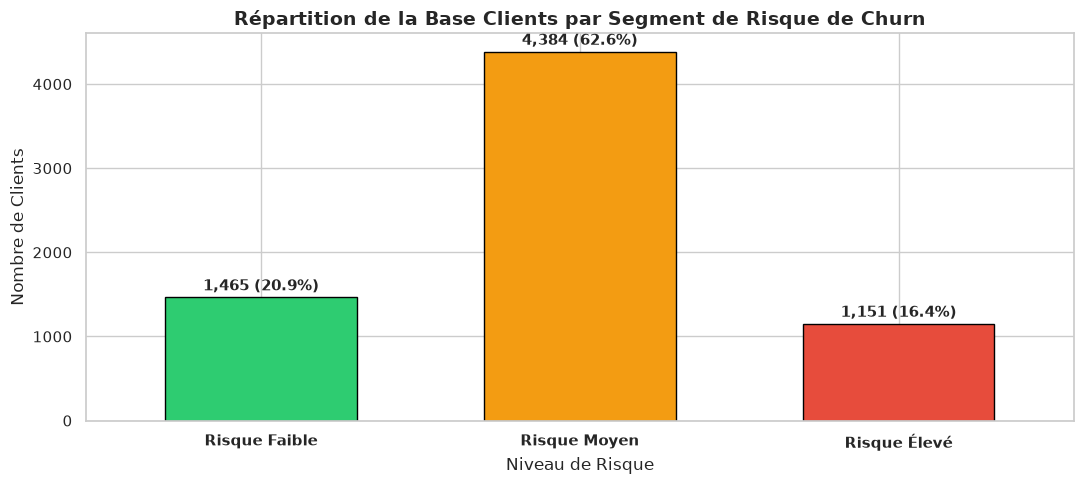

In [17]:
# ============================================================
# 16. VISUALISATION DES SEGMENTS DE RISQUE
# ============================================================

plt.figure(figsize=(11, 5))
risk_counts = df_scored["churn_risk_level"].value_counts().reindex(["Risque Faible", "Risque Moyen", "Risque Élevé"])
bar_colors = ["#2ecc71", "#f39c12", "#e74c3c"]

ax = risk_counts.plot(kind="bar", color=bar_colors, edgecolor="black", width=0.6)
plt.title("Répartition de la Base Clients par Segment de Risque de Churn", fontsize=14, weight="bold")
plt.xlabel("Niveau de Risque", fontsize=12)
plt.ylabel("Nombre de Clients", fontsize=12)
plt.xticks(rotation=0, fontsize=11, weight="bold")

tot = len(df_scored)
for p in ax.patches:
    height = p.get_height()
    pct = (height / tot) * 100
    ax.annotate(f"{int(height):,} ({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2., height + 40),
                ha="center", va="bottom", fontsize=11, weight="bold")

plt.tight_layout()
plt.savefig("results/risk_segments_distribution.png", dpi=300)
plt.show()

## 17. 📋 Synthèse Exécutive & Recommandations Stratégiques

### Q&A
- **Q : Quel algorithme offre le meilleur compromis de détection du Churn ?**
  - **R :** **XGBoost Classifier** et **Random Forest** surpassent nettement la Régression Logistique grâce à leur capacité à capturer les interactions non-linéaires complexes entre la récence, la fréquence d'achat et le montant dépensé.
- **Q : Quels sont les signaux avant-coureurs les plus critiques d'un départ client ?**
  - **R :** La **Récence (Recency_Days)** est de loin le facteur prédictif n°1. Un client dont le délai depuis la dernière visite dépasse le cycle habituel d'achat présente une probabilité d'attrition qui augmente de façon exponentielle. Viennent ensuite la **Fréquence historique** et le **Montant total dépensé**.

### Points Clés de l'Analyse
- **Rigueur méthodologique** : Aucune fuite d'information grâce à un fenêtrage temporel propre (période d'observation RFM distincte de la période de validation du churn).
- **Prise en compte du déséquilibre** : Utilisation de `class_weight='balanced'` et de `scale_pos_weight` pour garantir un taux de rappel (*Recall*) élevé, évitant ainsi de rater des clients sur le point de partir.
- **Génération d'actifs réutilisables** : Le modèle sérialisé (`models/churn_model.pkl`) et la base scorée (`data/predictions_churn.csv`) sont directement exploitables par les outils CRM et les plateformes d'automatisation marketing.

### Prochaines Étapes Opérationnelles
1. **Déploiement CRM en temps réel** : Automatiser le recalcul hebdomadaire du score de churn via le modèle sauvegardé.
2. **A/B Testing des offres de rétention** : Tester l'efficacité relative d'une réduction directe (ex. -20%) versus un bon d'achat ou une offre cadeau sur le segment *Risque Élevé*.